In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/flowers_split"
!ls

/content/drive/MyDrive/flowers_split
test  train


In [3]:
!nvidia-smi

Sun Apr 19 22:48:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Data Augmentation
Usamos ImageDataGenerator para generar imagenes nuevas en el ram mientras entrenamos para no desperdiciar espacio.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

train_dir = 'train'
test_dir = 'test'

Debido a que mi conexión a internet es inestable, genero una copia de los archivos para que sean leidos de manera "local", agilizando el tiempo de entrenamiento del modelo

In [5]:
!cp -r "/content/drive/MyDrive/flowers_split/train" /content/
!cp -r "/content/drive/MyDrive/flowers_split/test" /content/
!ls /content/train

black_eyed_susan  common_daisy	dandelion  rose       water_lily
calendula	  coreopsis	iris	   sunflower
california_poppy  daffodil	magnolia   tulip


In [6]:
train_dir = '/content/train'
test_dir = '/content/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True
)

En este caso estamos tomando 32 imágenes y estamos modificando todas 1 vez cada una y las mostramos a manera de ejemplo.

Found 10577 images belonging to 13 classes.
(32, 120, 120, 3)


<Figure size 640x480 with 0 Axes>

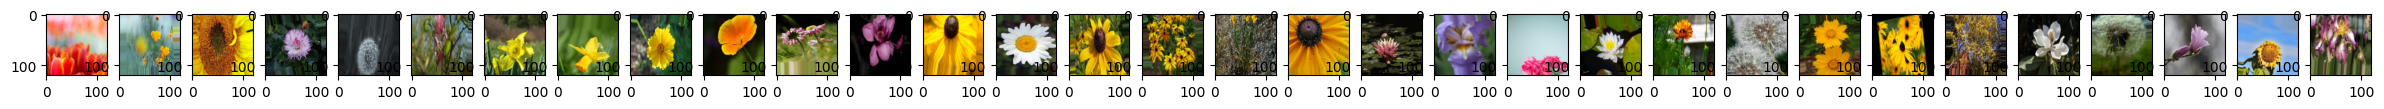

In [7]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (120, 120),
							batch_size = 32,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

Primereo modelo CNN basado en una arquitectura VGG simplificada.

In [9]:
model = models.Sequential()

# Receptores pequeños basado en VGG
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(120,120,3)))
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Aumento de profundidad y filtros
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Clasificador final con Dropout (evitar sobreajuste)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(13, activation='softmax'))

model.summary()

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,573 (275.68 KB)

 Trainable params: 70,573 (275.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 66s 172ms/step - accuracy: 0.1451 - loss: 2.4449
Epoch 2/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 72s 162ms/step - accuracy: 0.2206 - loss: 2.1900
Epoch 3/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 51s 155ms/step - accuracy: 0.2747 - loss: 2.0648
Epoch 4/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 53s 160ms/step - accuracy: 0.3055 - loss: 1.9736
Epoch 5/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 53s 160ms/step - accuracy: 0.3278 - loss: 1.9060
Epoch 6/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 150ms/step - accuracy: 0.3461 - loss: 1.8493
Epoch 7/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 52s 156ms/step - accuracy: 0.3617 - loss: 1.8080
Epoch 8/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 152ms/step - accuracy: 0.3704 - loss: 1.7791
Epoch 9/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 51s 152ms/step - accuracy: 0.3711 - loss: 1.7630
Epoch 10/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 52s 156ms/step - accuracy: 0.3884 - loss: 1.7255
Epoch 11/70
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 151ms/step - accuracy: 0.3939 - loss: 1.7094
Epoch 12/70
331/331

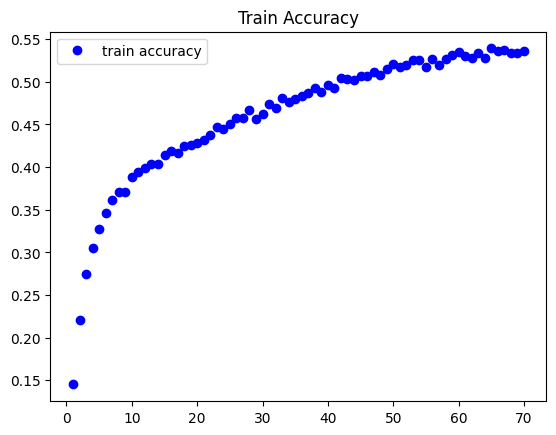

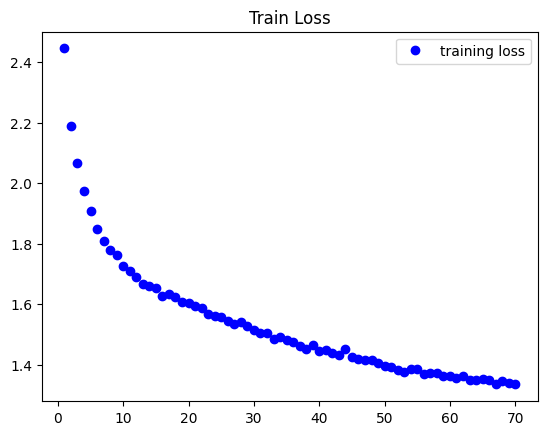

In [10]:
history = model.fit(
    train_generator,
    epochs=70,
)

acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='train accuracy')
plt.title('Train Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='training loss')
plt.title('Train Loss')
plt.legend()

plt.show()

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)

print('\nTest accuracy:\n', test_acc)

Found 2660 images belonging to 13 classes.
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5865 - loss: 1.2156

Test accuracy:
 0.5864661931991577


In [12]:
import numpy as np

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step


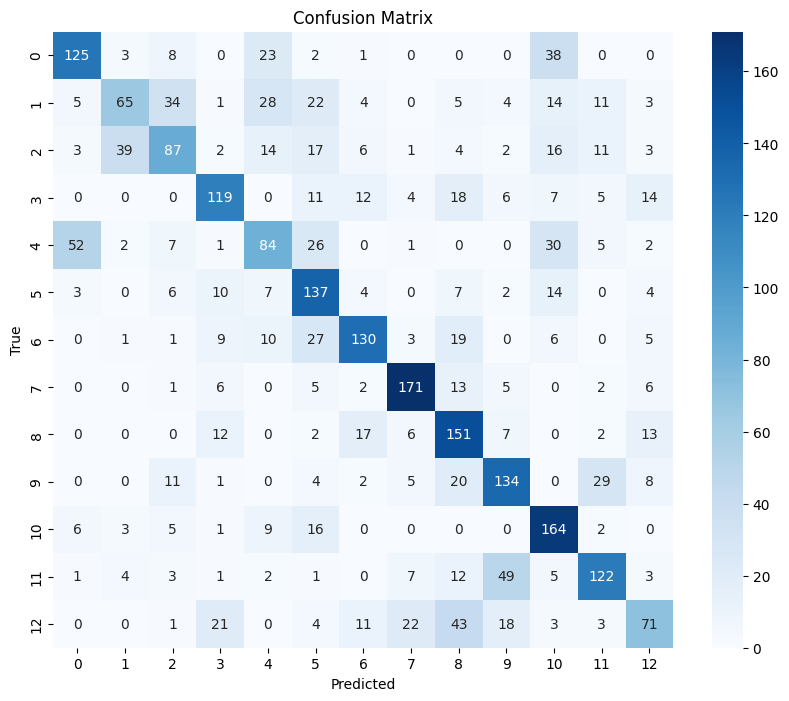

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.64      0.62      0.63       200
           1       0.56      0.33      0.42       196
           2       0.53      0.42      0.47       205
           3       0.65      0.61      0.63       196
           4       0.47      0.40      0.43       210
           5       0.50      0.71      0.59       194
           6       0.69      0.62      0.65       211
           7       0.78      0.81      0.79       211
           8       0.52      0.72      0.60       210
           9       0.59      0.63      0.61       214
          10       0.55      0.80      0.65       206
          11       0.64      0.58      0.61       210
          12       0.54      0.36      0.43       197

    accuracy                           0.59      2660
   macro avg       0.59      0.58      0.58      2660
weighted avg       0.59      0.59      0.58      2660



Intento de segunda iteración, pero me quedé sin tokens, aunque este modelo promete poseer mejores resultados.

In [30]:
modely = models.Sequential()

modely.add(layers.Input(shape=(120,120,3)))
modely.add(layers.Conv2D(32, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(32, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

modely.add(layers.Conv2D(64, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(64, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

modely.add(layers.GlobalAveragePooling2D())

modely.add(layers.Dense(64, activation='relu'))
modely.add(layers.Dropout(0.3))
modely.add(layers.Dense(13, activation='softmax'))

modely.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

model.summary()

Model: "functional_104"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 120, 120,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 60, 60,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 60, 60,    │      9,248 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 60, 60,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 60,    │          0 │ conv2d_7[0][0],   │
│                     │ 32)               │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 60, 60,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 30, 30,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 30, 30,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 30, 30,    │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 30,    │          0 │ conv2d_9[0][0],   │
│                     │ 64)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 30, 30,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 15, 15,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 81,933 (320.05 KB)

 Trainable params: 81,933 (320.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = modely.fit(
    train_generator,
    epochs=100,
)

acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='train accuracy')
plt.title('Train Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='training loss')
plt.title('Train Loss')
plt.legend()

plt.show()

Epoch 1/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 51s 154ms/step - accuracy: 0.6429 - loss: 1.0492
Epoch 2/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 49s 149ms/step - accuracy: 0.6484 - loss: 1.0416
Epoch 3/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 150ms/step - accuracy: 0.6558 - loss: 1.0330
Epoch 4/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 150ms/step - accuracy: 0.6585 - loss: 1.0326
Epoch 5/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 49s 148ms/step - accuracy: 0.6501 - loss: 1.0351
Epoch 6/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 151ms/step - accuracy: 0.6512 - loss: 1.0332
Epoch 7/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 49s 149ms/step - accuracy: 0.6484 - loss: 1.0421
Epoch 8/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 151ms/step - accuracy: 0.6505 - loss: 1.0396
Epoch 9/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 49s 147ms/step - accuracy: 0.6526 - loss: 1.0332
Epoch 10/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 50s 152ms/step - accuracy: 0.6507 - loss: 1.0233
Epoch 11/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 49s 147ms/step - accuracy: 0.6592 - loss: 1.0197
Epoch 12

In [1]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = modely.evaluate(test_generator)

print('\nTest accuracy:\n', test_acc)

import numpy as np

y_pred = modely.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

NameError: name 'ImageDataGenerator' is not defined